In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install kaggle shap lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=470bd470c1d324060d95b1e5e38f9e2091357a9f76a81eca191adfa07fad8aed
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json


{}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
import os
import zipfile

# Set project directory in Google Drive
project_dir = '/content/drive/MyDrive/TB_Project'
os.makedirs(project_dir, exist_ok=True)

# ✅ Download Datasets
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset -p {project_dir}
!kaggle datasets download -d victorcaelina/tuberculosis-symptoms -p {project_dir}

# ✅ Unzip Chest X-ray Dataset
with zipfile.ZipFile(f"{project_dir}/tuberculosis-tb-chest-xray-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{project_dir}/xray_data")

# ✅ Unzip Symptom Dataset
with zipfile.ZipFile(f"{project_dir}/tuberculosis-symptoms.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{project_dir}/symptom_data")


Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
Dataset URL: https://www.kaggle.com/datasets/victorcaelina/tuberculosis-symptoms
License(s): unknown


In [ ]:
# List files in symptom_data
!ls "{project_dir}/symptom_data"


'Tb disease symptoms.csv'
'Tb disease symptoms.json'
'Tb disease symptoms without id and datetime.csv'
'Tb disease symptoms without id and datetime.json'
'Tb disease symptoms.xlsx'
'Tb disease without id and datetime.xlsx'


In [ ]:
import pandas as pd

# Use exact file name with correct folder
symptom_path = "/content/drive/MyDrive/TB_Project/symptom_data/Tb disease symptoms.csv"

# Load the dataset
symptom_df = pd.read_csv(symptom_path)

# Show basic info
print(symptom_df.columns)
symptom_df.head()


Index(['no', 'id', 'name', 'gender', 'date', 'time', 'fever for two weeks',
       'coughing blood', 'sputum mixed with blood', 'night sweats ',
       'chest pain', 'back pain in certain parts ', 'shortness of breath',
       'weight loss ', 'body feels tired',
       'lumps that appear around the armpits and neck',
       'cough and phlegm continuously for two weeks to four weeks',
       'swollen lymph nodes', 'loss of appetite'],
      dtype='object')


,no,id,name,gender,date,time,fever for two weeks,coughing blood,sputum mixed with blood,night sweats,chest pain,back pain in certain parts,shortness of breath,weight loss,body feels tired,lumps that appear around the armpits and neck,cough and phlegm continuously for two weeks to four weeks,swollen lymph nodes,loss of appetite
0,1,8048761033,Noe,Male,12/10/2020,4:51 PM,0,1,1,1,1,1,1,1,0,0,1,0,1
1,2,793846900,Genna,Male,11/16/2020,9:35 AM,1,1,1,0,0,1,1,0,0,0,1,1,1
2,3,5619727459,Leesa,Male,1/18/2020,8:38 PM,0,0,1,1,0,1,0,0,0,1,1,1,1
3,4,4337104062,Case,Female,2/4/2020,3:09 PM,0,1,0,1,1,0,0,1,1,0,1,0,1
4,5,9507094539,Leola,Female,7/9/2020,5:51 PM,0,1,0,1,1,1,0,1,1,1,1,0,0


In [ ]:
# Strip and replace column names
symptom_df.columns = symptom_df.columns.str.strip().str.replace(' ', '_').str.lower()


In [ ]:
#Load and Preprocess Symptom Data

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 1: Load dataset
symptom_df = pd.read_csv("/content/drive/MyDrive/TB_Project/symptom_data/Tb disease symptoms.csv")

# Step 2: Drop irrelevant columns
drop_cols = ['no', 'id', 'name', 'gender', 'date', 'time']
symptom_df = symptom_df.drop(columns=drop_cols)

# ✅ Step 3: Clean column names (before doing anything else)
symptom_df.columns = symptom_df.columns.str.strip().str.replace(' ', '_').str.lower()

# Step 4: Assign TB label = 1
symptom_df['label'] = 1

# Step 5: Simulate 20 non-TB records with all 0s
non_tb = pd.DataFrame(np.zeros((20, symptom_df.shape[1])), columns=symptom_df.columns)
non_tb['label'] = 0

# Step 6: Combine the TB and non-TB data
data = pd.concat([symptom_df, non_tb], ignore_index=True)

# Step 7: Split into features and target
X = data.drop(columns=['label'])
y = data['label']

# ✅ Print column names once to confirm they’re clean
print(f"Columns used for training:\n{list(X.columns)}")

# Step 8: Train-test split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

# Step 9: Define and train the MLP model
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp_model.fit(X_train_scaled, y_train, epochs=10, validation_data=(X_test_scaled, y_test))


Columns used for training:
['fever_for_two_weeks', 'coughing_blood', 'sputum_mixed_with_blood', 'night_sweats', 'chest_pain', 'back_pain_in_certain_parts', 'shortness_of_breath', 'weight_loss', 'body_feels_tired', 'lumps_that_appear_around_the_armpits_and_neck', 'cough_and_phlegm_continuously_for_two_weeks_to_four_weeks', 'swollen_lymph_nodes', 'loss_of_appetite']
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8640 - loss: 0.5336 - val_accuracy: 0.9804 - val_loss: 0.2361
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9768 - loss: 0.1888 - val_accuracy: 0.9804 - val_loss: 0.0949
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9766 - loss: 0.0868 - val_accuracy: 0.9804 - val_loss: 0.0527
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9840 - loss: 0.0418 - val_accuracy: 0.9804 - val_loss: 0.0336
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9844 - loss: 0.0271 - val_accuracy: 1.0000 - val_loss: 0.0223
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 0.0155
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 1.0000 - val_loss: 0.0113
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0083
Ep

In [ ]:
# List files in your TB image folder
!ls "/content/drive/MyDrive/TB_Project/xray_data/TB_Chest_Radiography_Database/Tuberculosis"


Tuberculosis-100.png  Tuberculosis-311.png  Tuberculosis-522.png
Tuberculosis-101.png  Tuberculosis-312.png  Tuberculosis-523.png
Tuberculosis-102.png  Tuberculosis-313.png  Tuberculosis-524.png
Tuberculosis-103.png  Tuberculosis-314.png  Tuberculosis-525.png
Tuberculosis-104.png  Tuberculosis-315.png  Tuberculosis-526.png
Tuberculosis-105.png  Tuberculosis-316.png  Tuberculosis-527.png
Tuberculosis-106.png  Tuberculosis-317.png  Tuberculosis-528.png
Tuberculosis-107.png  Tuberculosis-318.png  Tuberculosis-529.png
Tuberculosis-108.png  Tuberculosis-319.png  Tuberculosis-52.png
Tuberculosis-109.png  Tuberculosis-31.png   Tuberculosis-530.png
Tuberculosis-10.png   Tuberculosis-320.png  Tuberculosis-531.png
Tuberculosis-110.png  Tuberculosis-321.png  Tuberculosis-532.png
Tuberculosis-111.png  Tuberculosis-322.png  Tuberculosis-533.png
Tuberculosis-112.png  Tuberculosis-323.png  Tuberculosis-534.png
Tuberculosis-113.png  Tuberculosis-324.png  Tuberculosis-535.png
Tuberculosis-114.png  Tube

In [ ]:
# Scale and Train MLP on Symptoms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp_model.fit(X_train_scaled, y_train, epochs=10, validation_data=(X_test_scaled, y_test))


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6876 - loss: 0.6037 - val_accuracy: 0.9804 - val_loss: 0.2590
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9823 - loss: 0.2011 - val_accuracy: 0.9804 - val_loss: 0.1114
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9789 - loss: 0.0974 - val_accuracy: 0.9804 - val_loss: 0.0651
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9798 - loss: 0.0582 - val_accuracy: 0.9804 - val_loss: 0.0423
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9790 - loss: 0.0399 - val_accuracy: 0.9804 - val_loss: 0.0284
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9807 - loss: 0.0292 - val_accuracy: 1.0000 - val_loss: 0.0191
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0141
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 0.0110
Ep

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:

# Initital configurations
SEED = 1234

def set_seeds(seed=1234):
    """Set seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # multi-GPU

# Set seeds for reproducibility
set_seeds(seed=SEED)

# Set device
cuda = True
device = torch.device("cuda" if (
    torch.cuda.is_available() and cuda) else "cpu")

In [ ]:
from torchvision.models import densenet121,DenseNet121_Weights, DenseNet

#model architecture
class CXR_DenseNetModel(nn.Module):
  """DenseNet121 pretrained model definition."""
  def __init__(self, num_classes):
      super(CXR_DenseNetModel, self).__init__()

      self.model = torchvision.models.densenet121(pretrained=True)

      # Freeze the model's parameters
      for param in self.model.parameters():
          param.requires_grad = False

      # Replace the last linear layer of the model
      in_features = self.model.classifier.in_features
      self.model.classifier = nn.Sequential(
          nn.Linear(in_features, in_features // 2),
          nn.Dropout(0.5),
          nn.Linear(in_features // 2, in_features // 4),
          # nn.Dropout(0.5),
          nn.Linear(in_features // 4, in_features // 8),
          nn.Dropout(0.25),
          nn.Linear(in_features // 8, num_classes),
      )

  def forward(self, x):
      return self.model(x)

model = CXR_DenseNetModel(num_classes=2)


# set device
model = model.to(device)
model


CXR_DenseNetModel(
  (model): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

In [ ]:
# loading model
import torch
PATH = "01_tuberculosis_model.pth"
model = torch.load(PATH,map_location=torch.device('cpu'),weights_only=False)

In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 36.3 MB/s eta 0:00:00


In [ ]:
# saving the model in onnx format
import torch.onnx

 # set the model to inference mode
model.eval()

# Input to the model
x = torch.randn(1, 3, 224, 224, requires_grad=True)

input_names = [ "actual_input" ]
output_names = [ "output" ]

torch.onnx.export(model,
                 x,
                 "tuberModel.onnx",
                 verbose=False,
                 input_names=input_names,
                 output_names=output_names,
                 export_params=True,
                 )

In [ ]:
sample = pd.DataFrame([[
    1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0  # Match your 13 features
]], columns=X.columns)

sample_scaled = scaler.transform(sample).astype('float32')


In [ ]:
import torchvision.transforms as transforms

def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')  # Ensure 3 channels
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0)  # Shape: (1, 3, 224, 224)
    return img_tensor

image_tensor = preprocess_image("Normal-10.png")

In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.9 MB/s eta 0:00:00


In [ ]:
# Inference from image model (ONNX)
import onnxruntime as ort

ort_session = ort.InferenceSession("tuberModel.onnx")
ort_inputs = {ort_session.get_inputs()[0].name: image_tensor.numpy()}
ort_outs = ort_session.run(None, ort_inputs)

logits = ort_outs[0][0]
probs = F.softmax(torch.tensor(logits), dim=0).numpy()

img_pred = probs[1]

# Inference from symptom model (Keras)
symptom_pred = mlp_model.predict(sample_scaled)[0][0]

# Combine predictions
final_score = (img_pred + symptom_pred) / 2
final_label = 1 if final_score > 0.5 else 0

print(f"Image Model: {img_pred:.3f}, Symptom Model: {symptom_pred:.3f}, Final: {final_score:.3f} → Label: {'TB' if final_label else 'No TB'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Image Model: 0.000, Symptom Model: 0.927, Final: 0.463 → Label: No TB


In [ ]:
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import cv2
import numpy as np
import pandas as pd
from IPython.display import display, HTML

def mlp_predict_proba(x):
    p = mlp_model.predict(x)
    return np.concatenate([1 - p, p], axis=1)  # shape: (n_samples, 2)


lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=["No TB", "TB"],
    discretize_continuous=True
)

lime_exp_sym = lime_explainer.explain_instance(
    sample_scaled[0],
    mlp_predict_proba,
    num_features=5
)
lime_exp_sym.show_in_notebook()


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
from torchvision import datasets, models, transforms
import torchvision.transforms as transforms
from PIL import Image

transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_img_explainer = lime_image.LimeImageExplainer()

def predict_image(imgs):
    # LIME will send batches of shape (H, W, 3), convert and preprocess
    imgs_tensor = torch.stack([transform(Image.fromarray(img.astype(np.uint8))) for img in imgs])
    ort_inputs = {ort_session.get_inputs()[0].name: imgs_tensor.numpy()}
    logits = ort_session.run(None, ort_inputs)[0]
    probs = F.softmax(torch.tensor(logits), dim=1).numpy()
    return probs

explanation = lime_img_explainer.explain_instance(
    image_tensor.squeeze().permute(1, 2, 0).numpy(),
    predict_image,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    label=1, positive_only=True, hide_rest=False
)

plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation for X-ray")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Got invalid dimensions for input: actual_input for the following indices
 index: 0 Got: 10 Expected: 1
 Please fix either the inputs/outputs or the model.

45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 326ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 305ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 315ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 299ms/step


PermutationExplainer explainer: 2it [05:27, 328.00s/it]              


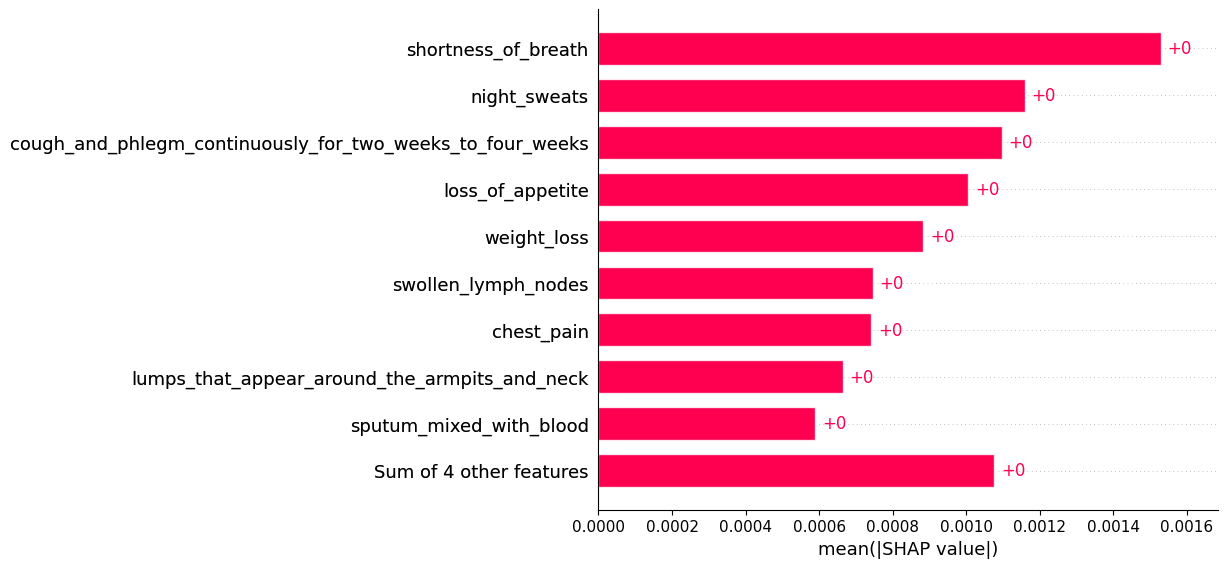

In [ ]:
import shap

explainer_sym = shap.Explainer(
    lambda x: combined_model.predict([x, np.repeat(img_input, x.shape[0], axis=0)]),
    X_train_scaled,
    feature_names=X.columns.tolist()
)
shap_values_sym = explainer_sym(sample_scaled)
shap.plots.bar(shap_values_sym)


157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 312ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

🔎 Final Prediction: TB (TB probability = 0.98)

🧾 Symptoms Reported:
  • Fever For Two Weeks — ✅ Present
  • Coughing Blood — ✅ Present
  • Sputum Mixed With Blood — ✅ Present
  • Night Sweats — ✅ Present
  • Chest Pain — ✅ Present
  • Back Pain In Certain Parts — ❌ Absent
  • Shortness Of Breath — ✅ Present
  • Weight Loss — ✅ Present
  • Body Feels Tired — ✅ Present
  • Lumps That Appear Around The Armpits And Neck — ❌ Absent
  • Cough And Phlegm Continuously For Two Weeks To Four Weeks — ✅ Present
  • Swollen Lymph Nodes — ✅ Present
  • Loss Of Appetite — ✅ Present

🫁 Chest X-ray Image Used:


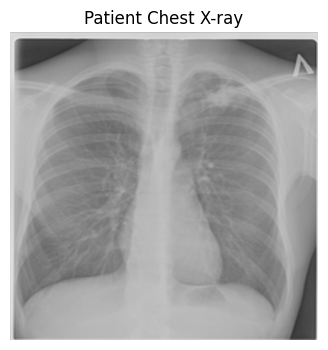


📊 SHAP Explanation (Top 5 Influential Symptoms):
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 330ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 339ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 315ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 315ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 303ms/step


PermutationExplainer explainer: 2it [05:36, 336.40s/it]              


  • shortness of breath: 0.0015 → ↑ toward TB
  • night sweats: 0.0012 → ↑ toward TB
  • cough and phlegm continuously for two weeks to four weeks: 0.0011 → ↑ toward TB
  • loss of appetite: 0.0010 → ↑ toward TB
  • weight loss: -0.0009 → ↓ toward No TB


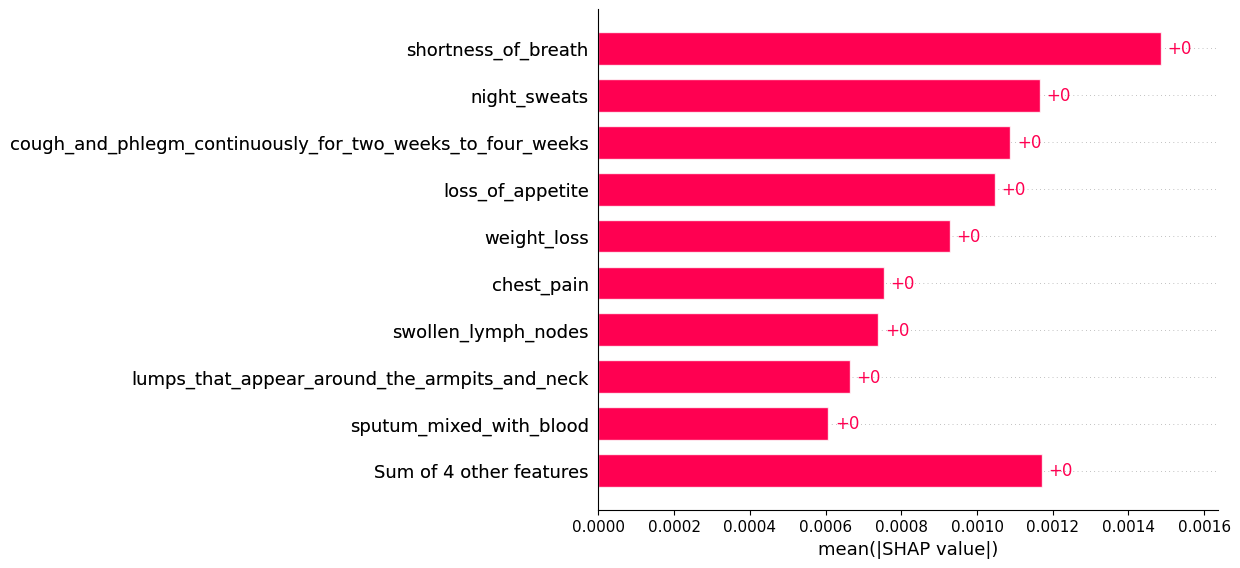


📌 LIME Explanation:
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 315ms/step



✅ Final Explanation Complete — Prediction and key symptom factors explained.


In [ ]:
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import cv2
import numpy as np
import pandas as pd
from IPython.display import display, HTML

def final_tb_summary(symptom_vector_scaled, symptom_vector_original, xray_path, xray_img_array):
    # ---------------------------------------------
    # 📌 1. Predict TB from combined model
    # ---------------------------------------------
    tb_prob = combined_model.predict([symptom_vector_scaled, xray_img_array])[0][0]
    prediction = "TB" if tb_prob > 0.5 else "No TB"
    print(f"\n🔎 Final Prediction: {prediction} (TB probability = {tb_prob:.2f})")

    # ---------------------------------------------
    # 📋 2. Show Symptoms Used
    # ---------------------------------------------
    print("\n🧾 Symptoms Reported:")
    symptom_bool = symptom_vector_original.values.flatten().astype(bool)
    for i, present in enumerate(symptom_bool):
        status = "✅ Present" if present else "❌ Absent"
        print(f"  • {X.columns[i].replace('_', ' ').title()} — {status}")

    # ---------------------------------------------
    # 🖼️ 3. Show Chest X-ray
    # ---------------------------------------------
    print("\n🫁 Chest X-ray Image Used:")
    img = cv2.imread(xray_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Patient Chest X-ray")
    plt.show()

    # ---------------------------------------------
    # 📊 4. SHAP Explanation
    # ---------------------------------------------
    print("\n📊 SHAP Explanation (Top 5 Influential Symptoms):")
    explainer = shap.Explainer(
        lambda x: combined_model.predict([x, np.repeat(xray_img_array, x.shape[0], axis=0)]),
        X_train_scaled,
        feature_names=X.columns.tolist()
    )
    shap_values = explainer(symptom_vector_scaled)
    top_shap = sorted(zip(X.columns, shap_values.values[0]), key=lambda x: abs(x[1]), reverse=True)[:5]

    for name, val in top_shap:
        direction = "↑ toward TB" if val > 0 else "↓ toward No TB"
        print(f"  • {name.replace('_', ' ')}: {val:.4f} → {direction}")

    shap.plots.bar(shap_values)

    # ---------------------------------------------
    # 🧾 5. LIME Explanation
    # ---------------------------------------------
    print("\n📌 LIME Explanation:")
    lime_explainer = LimeTabularExplainer(
        X_train_scaled,
        feature_names=X.columns.tolist(),
        class_names=["No TB", "TB"],
        discretize_continuous=True
    )

    def predict_proba(x):
        p = combined_model.predict([x, np.repeat(xray_img_array, x.shape[0], axis=0)])
        return np.concatenate([1 - p, p], axis=1)

    lime_exp = lime_explainer.explain_instance(
        symptom_vector_scaled[0],
        predict_proba,
        num_features=5
    )
    lime_exp.show_in_notebook()

    print("\n✅ Final Explanation Complete — Prediction and key symptom factors explained.")

# --------------------------------------------------
# 🧪 Run the final summary using your inputs:
# --------------------------------------------------
final_tb_summary(sample_scaled, sample, xray_path, img_input)
